# Random forest model
The file loaded here is a file where predictions have been made on 218 antibodies (called the biobhi data set). These predictions have then been computed into scores. Each row represents an antibody and each column is a tool. THere is one column for the antibody name, and one column with ADA percantage, this is clinically measured data, and it is used as the response variable.\
In this script the antibodies are divided into 3 groups of low, medium and high ADA percantage. \
This is done because predictions made previously (in the model selection scripts) are not showing good results. Especially are they bad at targeting antibodies that have high ADA percentage. One reason for this could be that there are not as many antibdoies with high ADA and therefor the data gets sqewed and the predictions worse. This is especilly important because it is of interest to catch the antibodies with high ADA. 


In [1]:
# load libaries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score, ConfusionMatrixDisplay, classification_report

In [2]:
# Load table with all computed scores for all tools
computed_scors_biophi = pd.read_csv("../3.feature_selection/biophi_dataSet/all_predictors_224AB(biophidata).csv")
computed_scors_biophi 

,antibody,ADA_percentage,netMHC1_pep9_percentile,class1pMHC_immunogen_pep9,basicPreProcessMCH1_pep9,netMHC1_pep14_percentile,class1pMHC_immunogen_pep14,basicPreProcessMCH1_pep14,netMHC_II_pep12_percentile,CD4Episcore_pep12,netMHC_II_pep15_percentile,CD4Episcore_pep15,MHCII_NP_pep15_cleavProb,MHCII_NP_pep15_cleavProbPercentile,waltz_nr_aggs,biophi_KabKabRelaxed_score,biophi_KabKabStrict_score
0,3f8,100.00,3.445306,37.674419,-3.373804,0.229277,38.095238,-3.531327,8.010336,99.118753,10.229277,94.757871,0.114987,29.354146,51,0.497585,0.188406
1,abagovomab,68.10,2.837241,44.495413,-3.417786,0.243436,41.314554,-3.561854,7.838071,99.484626,9.043928,95.568972,0.120447,24.888571,53,0.433333,0.180952
2,abciximab,35.50,3.227999,39.908257,-3.443564,0.208659,37.558685,-3.587375,8.354866,99.494547,9.043928,96.271372,0.119223,26.229048,23,0.428571,0.147619
3,abrilumab,0.40,2.508961,39.170507,-3.543928,0.192173,35.377358,-3.673514,7.579673,99.620457,9.130060,96.304235,0.146311,29.753171,30,0.985646,0.837321
4,actoxumab,0.00,2.966315,44.343891,-3.409749,0.240055,41.203704,-3.548555,7.996633,99.447036,7.665805,96.583658,0.095804,31.544048,39,0.924883,0.835681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,caplacizumab,11.00,3.549383,53.333333,-3.381630,0.193237,60.000000,-3.505279,11.419753,98.935075,10.466989,94.663083,0.121135,32.588182,7,0.608333,0.391667
220,2rs15d,20.00,2.596054,41.121495,-3.471023,0.108932,47.058824,-3.568047,5.291005,99.488019,4.409171,95.527548,0.137821,23.978421,25,0.392523,0.168224
221,gontivimab_alx-0171,34.10,2.944748,61.065574,-3.475876,0.247947,61.924686,-3.606141,9.750567,99.351057,7.716049,95.516623,0.155020,23.435319,80,0.457627,0.169492
222,vobarilizumab,41.00,2.842755,41.228070,-3.435665,0.298954,34.080717,-3.571817,7.160494,99.149196,6.748971,95.134060,0.151941,22.027045,38,0.752667,0.550037


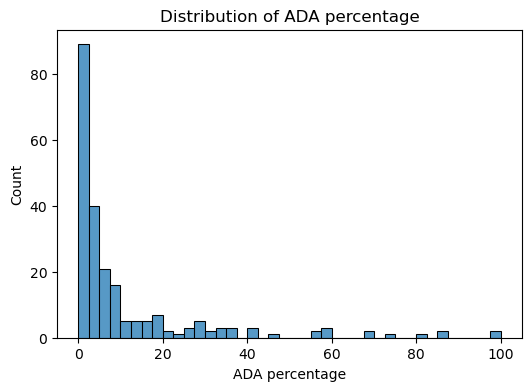

In [3]:
# Plot distribution of ADA percantage among the antibodies

plt.figure(figsize=(6,4))
sns.histplot(computed_scors_biophi['ADA_percentage'], bins=40)

plt.title('Distribution of ADA percentage')
plt.xlabel('ADA percentage')
plt.ylabel('Count')
plt.show()

In [4]:
# Add a column to the computed_scors_biophi df called "ADA group", 
# in this column each row is assigned "low", "medium" or "high"
# low is rows with ADA_percentage below 10
# medium is rows wtih ADA_percentage 10 to 30
# high is rows with ADA_percentage above 30
computed_scors_biophi['ADA_group'] = 2 # medium

computed_scors_biophi.loc[computed_scors_biophi['ADA_percentage'] < 10, 'ADA_group'] = 1 # low
computed_scors_biophi.loc[computed_scors_biophi['ADA_percentage'] > 30, 'ADA_group'] = 3 # high


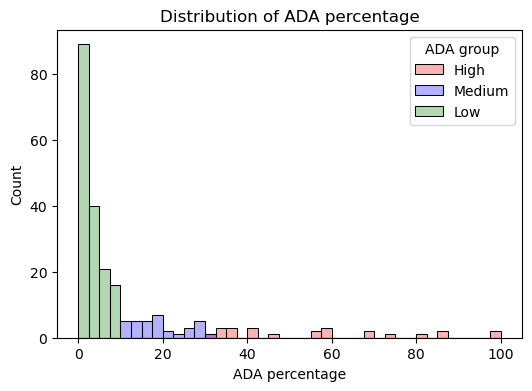

In [5]:
# Plot distribution of ADA percantage among the antibodies, color based on ADA group

plt.figure(figsize=(6,4))
sns.histplot(data = computed_scors_biophi, x='ADA_percentage', bins=40, hue='ADA_group', palette=['green', 'blue', 'red'], alpha=0.3)

plt.title('Distribution of ADA percentage')
plt.legend(title='ADA group', labels=['High', 'Medium', 'Low'])
plt.xlabel('ADA percentage')
plt.ylabel('Count')
plt.show()

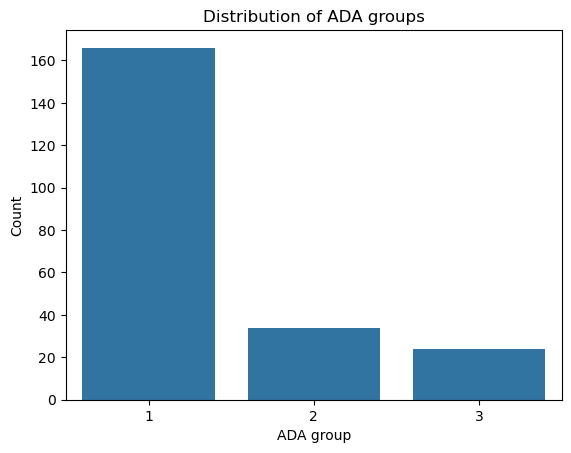

In [6]:
# plot the distribution of low, medium and high ADA percanteg
sns.countplot(
    data=computed_scors_biophi,
    x='ADA_group'
)

plt.title('Distribution of ADA groups')
plt.xlabel('ADA group')
plt.ylabel('Count')
plt.show()

Here features are removed for the random forest model\
I dont want to have to make this many predictions when making predictions in the future\
Consideration is taken to:\
- highly correlated featurs (one is removed)
- features selected in the Lasso regression
- included features should have the same settings, to make it easier when building a therapeutic profiler\
\
Featuers selected are:\
class1pMHC_immunogen_pep9\
netMHC_II_pep15_percentile\
MHCII_NP_pep15_cleavProbPercentile \
CD4Episcore_pep15\
waltz_nr_aggs\
netMHC1_pep9_percentile\
\
These features are selected more than 50% of runs in the Lasso regression.\
One feature (CD4Episcore_pep12) is selected 92% of times in the lasso regression but is removed anyways. This is because the very similar feature, CD4Episcore_pep15, is included and they are different settings on the same tool and score type. THe setting kept is present in other features and is the default setting. 

In [7]:

dowscaled_computed_scores = computed_scors_biophi.drop(columns=[
    'antibody', 'ADA_percentage', 'ADA_group', # response variable
    'biophi_KabKabRelaxed_score', 'basicPreProcessMCH1_pep9', 'class1pMHC_immunogen_pep14', # highly correlated features
    'netMHC1_pep14_percentile', 'MHCII_NP_pep15_cleavProb', 'basicPreProcessMCH1_pep14',
    'netMHC_II_pep12_percentile', # features low importance in lasso regression
    'CD4Episcore_pep12' # is important in lasso regression, but would add an extra prediction step due to different settings
])

# Random forest

Mean AUC: 0.7427271647869674
Std AUC: 0.058935012086901585


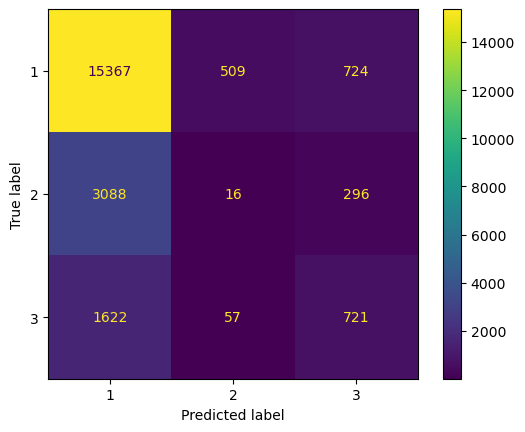

In [8]:
seeds = range(100)

all_auc = []

y_true_all = []
y_pred_all = []

X = dowscaled_computed_scores
y = computed_scors_biophi['ADA_group']

for seed in seeds:
    # StratifiedKFold to split the data into 5 folds, stratified on the response variable (ADA group)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    fold_auc = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=seed # random state gives different trees for each run 
        )
        #class_weight={1:1, 2:1, 3:3}  # increase weight for high ADA (class 3)

        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)
        y_pred = model.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        ''' ovr = one vs rest
        Class 1 vs (2+3)
        Class 2 vs (1+3)
        Class 3 vs (1+2) '''
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        fold_auc.append(auc)

    all_auc.extend(fold_auc)

print("Mean AUC:", np.mean(all_auc))
print("Std AUC:", np.std(all_auc))

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true_all,
    y_pred_all,
    normalize=None  # or 'true' for row-normalized
)

plt.show()


**Recall** \
is true positives (predicted) divided by the nr of actual positives.\
So here, for example, it is the number of correctly predicted high ADA divided by the actual number of high ADA.\
Correctly predicted high ADA = 72\
Actual number of high ADA = 161 + 7 + 72 = 240\
Recal high ADA = 72 / 240 = 0.3\
Answers the question: Are we catching anitbodies with high ADA? -> 30% of them, so no\
\
**Precision**\
is the true positives divided by the nr of predicted positives.\
So for example the number of correctly predicted high ADA divided by the correctly predicted high ADA, and the incorectly predicted high ADA.\
Correctly predicted high ADA = 72\
Incorecctly predicted high ADA = 76 + 29 = 105\
Precision high ADA = 72 / (72+105) = 0.4\
Answers the question: Are high ADA predictions actually correct? -> 40% of them, so no.\
\
**F1 score**\
F1 = 2 * (precision + recall) / (precision * recall)\
F1 is high only if both precision and recall is high.​\
\
**Support**\
Is the number of true samples for each class\
\
**Accuracy**\
Correct predictions / total predictions\
\
**macro avg**\
is just all precision divided by 3, same for all other nrs\
ex: (0.77 + 0.05 + 0.41) / 3 = 0.41\
\
**weighted avg**\
Like macro avg but each value is multiplied with its support

In [9]:
# Zero_division=0 handels if something is never predicted, so it dosent throw an error when have to divide by zero
print(classification_report(y_true_all, y_pred_all, zero_division=0))

              precision    recall  f1-score   support

           1       0.77      0.93      0.84     16600
           2       0.03      0.00      0.01      3400
           3       0.41      0.30      0.35      2400

    accuracy                           0.72     22400
   macro avg       0.40      0.41      0.40     22400
weighted avg       0.62      0.72      0.66     22400



# Random forest with weighted classes
class_weight={1:1, 2:1, 3:3}

Mean AUC: 0.7433860443425111
Std AUC: 0.05697663805316857


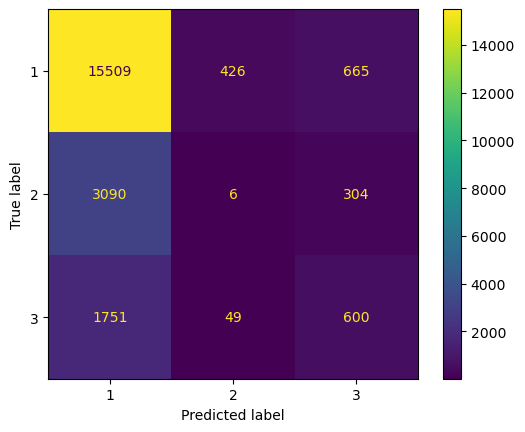

              precision    recall  f1-score   support

           1       0.76      0.93      0.84     16600
           2       0.01      0.00      0.00      3400
           3       0.38      0.25      0.30      2400

    accuracy                           0.72     22400
   macro avg       0.39      0.40      0.38     22400
weighted avg       0.61      0.72      0.65     22400



In [10]:
seeds = range(100)

all_auc = []

y_true_all = []
y_pred_all = []

X = dowscaled_computed_scores
y = computed_scors_biophi['ADA_group']

for seed in seeds:
    # StratifiedKFold to split the data into 5 folds, stratified on the response variable (ADA group)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    fold_auc = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=seed, # random state gives different trees for each run 
            class_weight={1:1, 2:1, 3:3}  # increase weight for high ADA (class 3)
        )
        

        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)
        y_pred = model.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        ''' ovr = one vs rest
        Class 1 vs (2+3)
        Class 2 vs (1+3)
        Class 3 vs (1+2) '''
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        fold_auc.append(auc)

    all_auc.extend(fold_auc)

print("Mean AUC:", np.mean(all_auc))
print("Std AUC:", np.std(all_auc))

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true_all,
    y_pred_all,
    normalize=None  # or 'true' for row-normalized
)

plt.show()

# Zero_division=0 handels if something is never predicted, so it dosent throw an error when have to divide by zero
print(classification_report(y_true_all, y_pred_all, zero_division=0))


# Random forest with even heavier weights


Mean AUC: 0.74214338789636
Std AUC: 0.057810047569882866


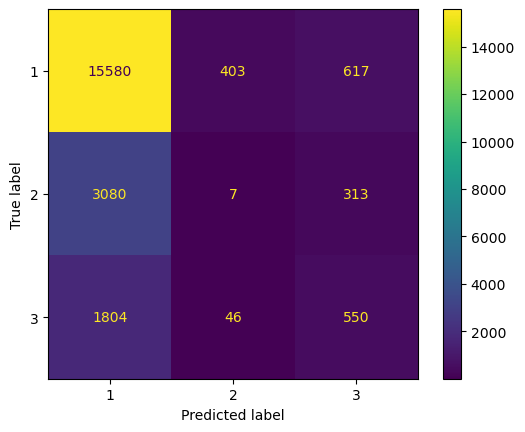

              precision    recall  f1-score   support

           1       0.76      0.94      0.84     16600
           2       0.02      0.00      0.00      3400
           3       0.37      0.23      0.28      2400

    accuracy                           0.72     22400
   macro avg       0.38      0.39      0.38     22400
weighted avg       0.61      0.72      0.65     22400



In [11]:
seeds = range(100)

all_auc = []

y_true_all = []
y_pred_all = []

X = dowscaled_computed_scores
y = computed_scors_biophi['ADA_group']

for seed in seeds:
    # StratifiedKFold to split the data into 5 folds, stratified on the response variable (ADA group)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    fold_auc = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=seed, # random state gives different trees for each run 
            class_weight={1:1, 2:1, 3:5}  # increase weight for high ADA (class 3)
        )
        

        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)
        y_pred = model.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        ''' ovr = one vs rest
        Class 1 vs (2+3)
        Class 2 vs (1+3)
        Class 3 vs (1+2) '''
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
        fold_auc.append(auc)

    all_auc.extend(fold_auc)

print("Mean AUC:", np.mean(all_auc))
print("Std AUC:", np.std(all_auc))

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true_all,
    y_pred_all,
    normalize=None  # or 'true' for row-normalized
)

plt.show()

# Zero_division=0 handels if something is never predicted, so it dosent throw an error when have to divide by zero
print(classification_report(y_true_all, y_pred_all, zero_division=0))

# Random forest with medium and high ADA merged to one class

In [12]:
# merge medium and high ADA group into one group
computed_scors_biophi['ADA_group'] = computed_scors_biophi['ADA_group'].replace(3, 2)

Mean AUC: 0.7549926538108357
Std AUC: 0.07115720774496741


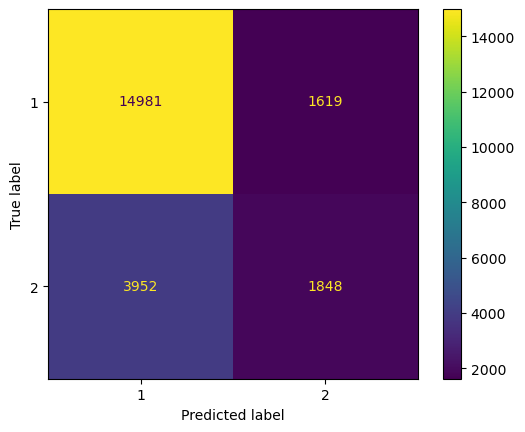

              precision    recall  f1-score   support

           1       0.79      0.90      0.84     16600
           2       0.53      0.32      0.40      5800

    accuracy                           0.75     22400
   macro avg       0.66      0.61      0.62     22400
weighted avg       0.72      0.75      0.73     22400



In [13]:
seeds = range(100)

all_auc = []

y_true_all = []
y_pred_all = []

X = dowscaled_computed_scores
y = computed_scors_biophi['ADA_group']

for seed in seeds:
    # StratifiedKFold to split the data into 5 folds, stratified on the response variable (ADA group)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    fold_auc = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=seed, # random state gives different trees for each run 
        )
        

        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)
        y_pred = model.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)


        auc = roc_auc_score(y_test, y_proba[:,1]) # calculate AUC for class 2 (medium/high ADA) vs class 1 (low ADA)
        fold_auc.append(auc)

    all_auc.extend(fold_auc)

print("Mean AUC:", np.mean(all_auc))
print("Std AUC:", np.std(all_auc))

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true_all,
    y_pred_all,
    normalize=None  # or 'true' for row-normalized
)

plt.show()

# Zero_division=0 handels if something is never predicted, so it dosent throw an error when have to divide by zero
print(classification_report(y_true_all, y_pred_all, zero_division=0))

Presision answers the question: Are we catching anitbodies with medium and high ADA? -> 53% of them, so kinda\
Recall answers the question: Are medium and high ADA predictions actually correct? -> 32% of them, so no.\

# Random forest with weights on the low ADA


Mean AUC: 0.7468366688273106
Std AUC: 0.07452509857227592


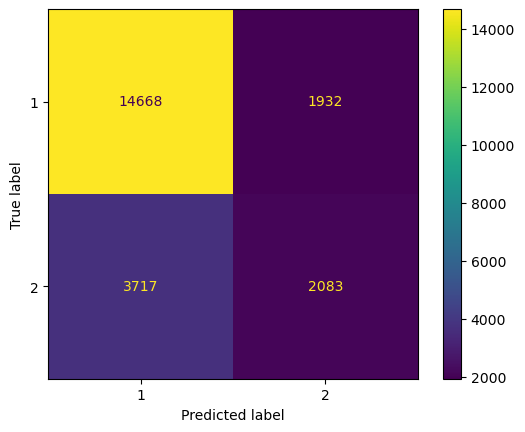

              precision    recall  f1-score   support

           1       0.80      0.88      0.84     16600
           2       0.52      0.36      0.42      5800

    accuracy                           0.75     22400
   macro avg       0.66      0.62      0.63     22400
weighted avg       0.73      0.75      0.73     22400



In [14]:
seeds = range(100)

all_auc = []

y_true_all = []
y_pred_all = []

X = dowscaled_computed_scores
y = computed_scors_biophi['ADA_group']

for seed in seeds:
    # StratifiedKFold to split the data into 5 folds, stratified on the response variable (ADA group)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    fold_auc = []

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=seed, # random state gives different trees for each run 
            class_weight={1:5, 2:1}  # increase weight for low ADA (class 1)
        )
        

        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)
        y_pred = model.predict(X_test)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)


        auc = roc_auc_score(y_test, y_proba[:,1]) # calculate AUC for class 2 (medium/high ADA) vs class 1 (low ADA)
        fold_auc.append(auc)

    all_auc.extend(fold_auc)

print("Mean AUC:", np.mean(all_auc))
print("Std AUC:", np.std(all_auc))

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_true_all,
    y_pred_all,
    normalize=None  # or 'true' for row-normalized
)

plt.show()

# Zero_division=0 handels if something is never predicted, so it dosent throw an error when have to divide by zero
print(classification_report(y_true_all, y_pred_all, zero_division=0))

Presision answers the question: Are we catching anitbodies with low ADA? -> 80% of them, so kinda\
Recall answers the question: Are low ADA predictions actually correct? -> 88% of them, so kinda.\

# Random forest model weights on high/medium ADA + probability prediction

In [15]:
# merge medium and high ADA group into one group
computed_scors_biophi['ADA_group'] = computed_scors_biophi['ADA_group'].replace(3, 2)

In [16]:



X = dowscaled_computed_scores
y = computed_scors_biophi['ADA_group']

X, X_val, y, y_val = train_test_split(
    X, y,
    test_size=0.1,
    stratify=y,
    random_state=42
)

In [17]:
# Run a model to select a threshold for high ADA


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store predictions aligned to original indices
y_true_oof = np.zeros(len(y), dtype=int)
y_proba_low_oof = np.zeros(len(y))

for train_idx, test_idx in skf.split(X, y):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight={1:1, 2:1}
    )

    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)

    # store predictions in correct positions
    y_true_oof[test_idx] = (y_test == 2) # class 2 (high/medium ADA) is treated as true, and optimized for
    y_proba_low_oof[test_idx] = y_proba[:, 1] # probability of class 2 (medium/high ADA)

    thresholds = np.linspace(0, 1, 101)
precScore = []
recallScore = []
f1Score = []

for t in thresholds:
    y_pred = (y_proba_low_oof > t)
    prec = precision_score(y_true_oof, y_pred, zero_division=0)
    precScore.append(prec)

    recall = recall_score(y_true_oof, y_pred, zero_division=0)
    recallScore.append(recall)

    f1 = f1_score(y_true_oof, y_pred, zero_division=0)
    f1Score.append(f1)

best_idx_prec = np.argmax(precScore)
best_threshold_prec = thresholds[best_idx_prec]

best_idx_recall = np.argmax(recallScore)
best_threshold_recall = thresholds[best_idx_recall]

best_idx_f1 = np.argmax(f1Score)
best_threshold_f1 = thresholds[best_idx_f1]

print("Best threshold:", best_threshold_prec)
print("precision_score:", precScore[best_idx_prec])

print("Best threshold:", best_threshold_recall)
print("recall_score:", recallScore[best_idx_recall])

print("Best threshold:", best_threshold_f1)
print("f1_score:", f1Score[best_idx_prec])


Best threshold: 0.41000000000000003
precision_score: 0.5777777777777777
Best threshold: 0.0
recall_score: 1.0
Best threshold: 0.31
f1_score: 0.5360824742268041


Mean AUC: 0.7624241379310345
Std AUC: 0.07966267986334531


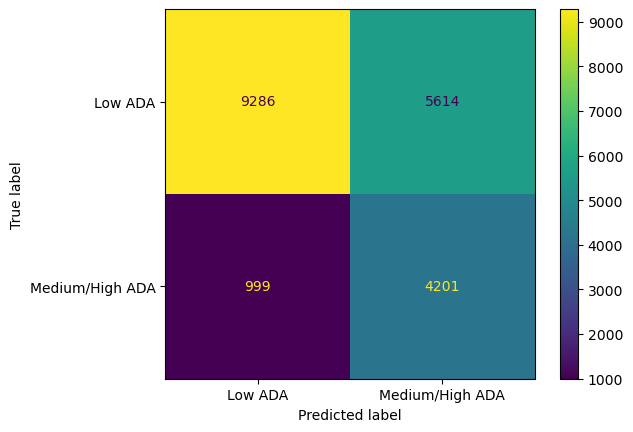

                 precision    recall  f1-score   support

        Low ADA       0.90      0.62      0.74     14900
Medium/High ADA       0.43      0.81      0.56      5200

       accuracy                           0.67     20100
      macro avg       0.67      0.72      0.65     20100
   weighted avg       0.78      0.67      0.69     20100



In [18]:
seeds = range(100)

all_auc = []
y_true_strict_all = []
y_pred_strict_all = []

for seed in seeds:
    # StratifiedKFold to split the data into 5 folds, stratified on the response variable (ADA group)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    for train_idx, test_idx in skf.split(X, y):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = RandomForestClassifier(
            n_estimators=200,
            random_state=seed, # random state gives different trees for each run 
            class_weight={1:1, 2:1}  # this code actually dosent do anything right now, but leaving it here so its easy to change weights later
        )
        

        model.fit(X_train, y_train)

        y_proba = model.predict_proba(X_test)

        # Only call something high  ADA” if probability > 20%
        y_proba_high = y_proba[:, 1]
        y_pred_high = (y_proba_high > 0.2)
      


        y_true_strict_all.extend(y_test == 2)
        y_pred_strict_all.extend(y_pred_high)

        auc = roc_auc_score(y_test, y_proba[:,1])
        all_auc.append(auc)


print("Mean AUC:", np.mean(all_auc))
print("Std AUC:", np.std(all_auc))

# Confusion matrix using strict predictions
ConfusionMatrixDisplay.from_predictions(y_true_strict_all, y_pred_strict_all, display_labels=["Low ADA", "Medium/High ADA"])
plt.show()

print(classification_report(
    y_true_strict_all,
    y_pred_strict_all,
    target_names=["Low ADA", "Medium/High ADA"],
    zero_division=0
))

Recall: Proportion of actual medium/high ADA that was classified correctly has medium/high ADA. -> This is important. This is the accuracy of well the model catches antibodies with high ADA. \
Precision: Proportion of all that are predicted as medium/high ADA that actually are medium/high ADA. -> Not so important here because if some low accedently are predicted as high thats fine. 

Validation AUC: 0.6666666666666667


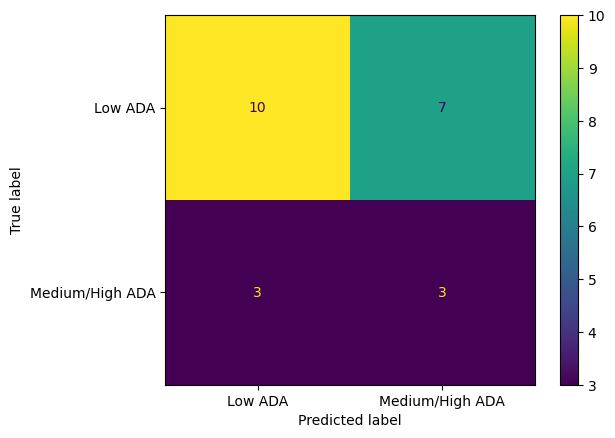

                 precision    recall  f1-score   support

        Low ADA       0.77      0.59      0.67        17
Medium/High ADA       0.30      0.50      0.38         6

       accuracy                           0.57        23
      macro avg       0.53      0.54      0.52        23
   weighted avg       0.65      0.57      0.59        23



In [19]:
# Train a final model with all the trainnig data and evaluate on the validation set
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight={1:1, 2:1}
)

final_model.fit(X, y)

# Probabilities
y_val_proba = final_model.predict_proba(X_val)

# AUC (still independent of threshold)
print("Validation AUC:", roc_auc_score(y_val, y_val_proba[:,1]))

threshold = 0.2

y_val_pred_strict = (y_val_proba[:, 1] > threshold)

# convert to labels for plotting
y_val_pred_labels = np.where(y_val_pred_strict, 2, 1)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_labels,
    display_labels=["Low ADA", "Medium/High ADA"]
)
plt.show()

print(classification_report(
    y_val,
    y_val_pred_labels,
    target_names=["Low ADA", "Medium/High ADA"],
    zero_division=0
))

Presision answers the question: Are we catching anitbodies with low ADA? -> 80% of them, so kinda\
Recall answers the question: Are low ADA predictions actually correct? -> 71% of them, so kinda.\